**Creating a small SQLite database (sales_data.db)**

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to SQLite database (this creates file automatically)
conn = sqlite3.connect("sales_data.db")

# Create cursor
cursor = conn.cursor()

**Creating one table called sales**

In [2]:
# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

conn.commit()

**Inserting some sample sales data**

In [3]:
sales_data = [
    ("Laptop", 5, 600),
    ("Mouse", 20, 20),
    ("Keyboard", 15, 30),
    ("Monitor", 7, 150)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)

conn.commit()

**Running SQL Queries and Printing the Output**

In [4]:
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)

print(df)

    product  total_qty  revenue
0  Keyboard         15    450.0
1    Laptop          5   3000.0
2   Monitor          7   1050.0
3     Mouse         20    400.0


**Showing a simple bar chart using matplotlib**

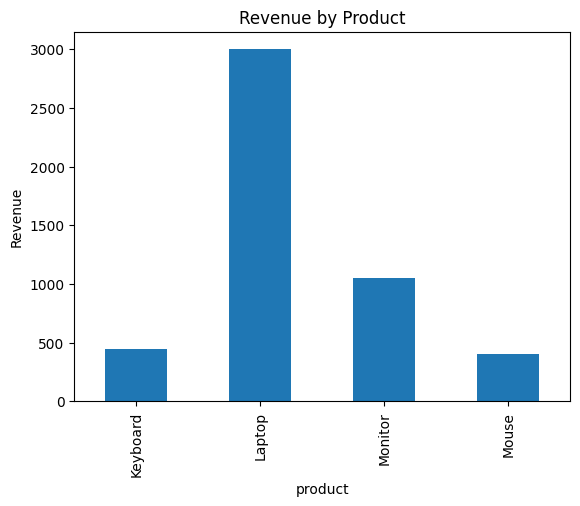

In [5]:
df.plot(kind="bar", x="product", y="revenue", legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()

**Closing connection**

In [6]:
conn.close()